In [83]:
import pandas as pd
import seaborn as sns
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# import plotly.express as px

In [69]:
load_dotenv()
database_url = os.getenv('DATABASE_URL')

engine = create_engine(database_url)

df = pd.read_sql('SELECT * FROM storm_events_details_cleaned', engine)

Creating a function where it changes the K's, M's and B's in damages to being actually float values

In [70]:
def written_to_full_amount(row):
    if row[-1:] == 'K':
        return float(row[:-1]) * 1000
    elif row[-1:] == 'M':
        return float(row[:-1]) * 1000000
    elif row[-1:] == 'B':
        return float(row[:-1]) * 1000000000
    else:
        return float(row)

In [71]:
df['DAMAGE_CROPS'].iloc[1][-1:]

'K'

In [72]:
df['DAMAGE_PROPERTY_FLOAT'] = df['DAMAGE_PROPERTY'].apply(written_to_full_amount)
df['DAMAGE_CROPS_FLOAT'] = df['DAMAGE_CROPS'].apply(written_to_full_amount)
df['Total_Damage_Cost'] = df['DAMAGE_CROPS_FLOAT'] + df['DAMAGE_PROPERTY_FLOAT']
df['END_DATE_TIME_DT'] = df['END_DATE_TIME'].apply(pd.to_datetime)

In [73]:
df['END_DATE_TIME_DT']

0       2025-03-31 11:06:00
1       2025-03-30 15:55:00
2       2025-06-19 15:29:00
3       2025-04-05 17:35:00
4       2025-04-05 04:25:00
                ...        
28462   2025-06-11 14:51:00
28463   2025-06-03 18:05:00
28464   2025-06-03 18:10:00
28465   2025-06-03 18:22:00
28466   2025-06-03 19:15:00
Name: END_DATE_TIME_DT, Length: 28467, dtype: datetime64[ns]

In [74]:
df.sort_values(by='Total_Damage_Cost',ascending=False)

,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,...,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,DATA_SOURCE,DAMAGE_PROPERTY_FLOAT,DAMAGE_CROPS_FLOAT,Total_Damage_Cost,END_DATE_TIME_DT
12669,202505,16,1342,202505,16,1349,202193,1262207,MISSOURI,29,...,38.6446,-90.3039,38.6894,-90.1974,"During the afternoon of May 16th, numerous sup...",CSV,1.600000e+09,0.0,1.600000e+09,2025-05-16 13:49:00
26127,202505,16,1715,202505,16,1732,202009,1274298,ILLINOIS,17,...,37.6553,-89.0945,37.6599,-88.7970,A 500mb shortwave trough moved across the Uppe...,CSV,2.500000e+07,0.0,2.500000e+07,2025-05-16 17:32:00
22282,202506,12,315,202506,12,851,204035,1272324,TEXAS,48,...,29.5100,-98.4100,29.5147,-98.4117,A mid-level shortwave trough moved over Texas ...,CSV,2.300000e+07,0.0,2.300000e+07,2025-06-12 08:51:00
26676,202505,16,1816,202505,16,1829,202011,1274626,KENTUCKY,21,...,37.6597,-88.0484,37.6548,-87.8679,A 500mb shortwave trough moved across the Uppe...,CSV,1.500000e+07,100000.0,1.510000e+07,2025-05-16 18:29:00
8676,202503,14,2227,202503,14,2247,200310,1241249,MISSOURI,29,...,36.7229,-90.5729,36.8607,-90.2986,A major outbreak of severe storms including to...,CSV,1.500000e+07,0.0,1.500000e+07,2025-03-14 22:47:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14,202506,30,1741,202506,30,1811,202499,1259481,MARYLAND,24,...,39.4900,-76.3900,39.5039,-76.3737,A boundary stalled across northeast Maryland a...,CSV,0.000000e+00,0.0,0.000000e+00,2025-06-30 18:11:00
15,202504,29,1506,202504,29,1506,201620,1257729,NEW YORK,36,...,42.9100,-77.7500,42.9100,-77.7500,"On Tuesday April 29, a cold front crossed the ...",CSV,0.000000e+00,0.0,0.000000e+00,2025-04-29 15:06:00
16,202505,19,1458,202505,19,1459,204187,1272368,KANSAS,20,...,39.0000,-94.6900,39.0000,-94.6900,Storms brought severe weather to eastern Kansas.,CSV,0.000000e+00,0.0,0.000000e+00,2025-05-19 14:59:00
17,202506,30,2015,202506,30,2030,202499,1259485,MARYLAND,24,...,39.5119,-76.3756,39.5130,-76.3734,A boundary stalled across northeast Maryland a...,CSV,0.000000e+00,0.0,0.000000e+00,2025-06-30 20:30:00


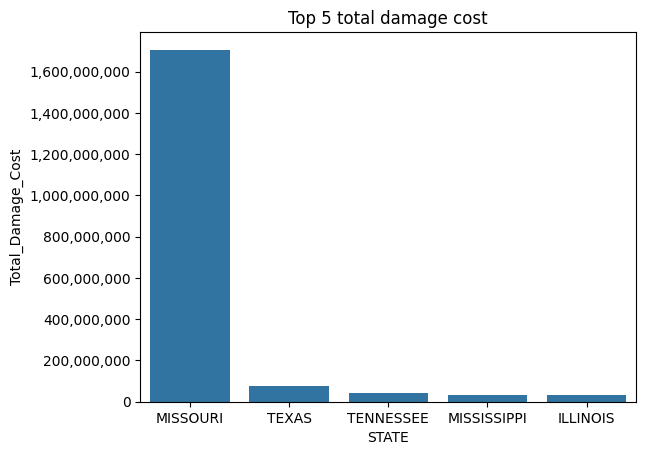

In [85]:
Grouped_State_df = df.groupby('STATE', as_index=False)['Total_Damage_Cost'].sum()
Grouped_State_df

ax = sns.barplot(Grouped_State_df.sort_values(by = 'Total_Damage_Cost',ascending = False).head(5),
                 x = 'STATE', y = 'Total_Damage_Cost')
ax.set(title = 'Top 5 total damage cost')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.show()

In [23]:
# df['END_DATE_TIME_DT'] = df['END_DATE_TIME_DT'].dt.to_period("M").dt.to_timestamp()
# df['END_DATE_TIME_DT'].nunique()

In [24]:
# nbformat
# plotly
# kaleido
# import plotly.io as pio

# fig = px.choropleth(
#     data_frame= df,
#     locations = 'STATE',
#     locationmode= 'USA-states',
#     color = 'Total_Damage_Cost',
#     scope = 'usa',
#     animation_frame= 'END_DATE_TIME_DT',
#     color_continuous_scale= 'Viridis'
# )


# fig.show()